# 푸리에 급수 — Python 실습

## 학습 목표
- 복소 푸리에 계수 $c_n$을 해석적 적분(SymPy)으로 직접 구한다
- 고조파 번호 $n$과 실제 주파수 $f = nf_0$의 관계를 이해한다
- 단순한 신호에서 복잡한 신호로 갈수록 더 많은 $c_n$이 필요함을 확인한다

In [ ]:
# Colab 환경 설정 (로컬에서는 아무 작업 없음)
import os, sys

if 'google.colab' in sys.modules:
    REPO = 'AI-PHM_Graduate'
    if not os.path.exists(REPO):
        !git clone -q https://github.com/jongmoonha/AI-PHM_Graduate.git
    sys.path.insert(0, f'/content/{REPO}')
    # 한글 폰트 설치 (matplotlib 글리프 경고 방지)
    !apt-get install -y -qq fonts-nanum > /dev/null
    import matplotlib.font_manager as fm
    for fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
        fm.fontManager.addfont(fp)


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from utils.style import setup_notebook, COLORS, LINE_COLORS
setup_notebook()

from utils import plot_fourier_coeffs, plot_partial_sum, square_wave_fourier

---
## 공통 도구: SymPy로 $c_n$ 계산

복소 푸리에 계수의 정의:

$$c_n = \frac{1}{T}\int_0^T x(t)\, e^{-jn\omega_0 t}\, dt \qquad (\omega_0 = 2\pi f_0,\; T = 1/f_0)$$

아래 함수는 이 적분을 SymPy로 **해석적**으로 수행한다.

In [2]:
t = sp.Symbol('t', real=True)

def compute_cn(x, f0=1, n_range=5):
    """c_n을 -n_range ~ +n_range까지 해석적으로 계산한다."""
    f0_sym = sp.Integer(f0)
    T = 1 / f0_sym
    w0 = 2 * sp.pi * f0_sym
    cn = {}
    for k in range(-n_range, n_range + 1):
        c_k = (1/T) * sp.integrate(x * sp.exp(-sp.I * k * w0 * t), (t, 0, T))
        cn[k] = c_k
    return cn

---
## 스펙트럼 표시 방법: $n$ 축 vs 주파수(Hz) 축

$c_n$을 구하면 스펙트럼을 그릴 수 있다. x축을 무엇으로 하느냐에 따라 두 가지 표현이 가능하다.

- **$n$ 축**: 고조파 번호. $c_n$ 값은 $f_0$와 무관하다.
- **주파수(Hz) 축**: $f = n 	imes f_0$. $f_0$에 따라 피크 위치가 달라진다.

아래에서 $\cos(\omega_0 t)$를 $f_0 = 1$ Hz와 $f_0 = 2$ Hz로 각각 분석하여 비교한다.

In [3]:
def plot_cn_n_vs_hz(cn, f0, title=""):
    """n축과 Hz축 스펙트럼을 나란히 그린다."""
    ns = np.array(sorted(cn.keys()))
    mags = np.array([float(abs(cn[n])) for n in ns])
    freqs = ns * f0
    max_n = max(abs(ns))

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    ml, sl, bl = axes[0].stem(ns, mags)
    plt.setp(sl, color=LINE_COLORS[0])
    plt.setp(ml, color=LINE_COLORS[0])
    plt.setp(bl, color="gray")
    axes[0].set_xlabel("$n$")
    axes[0].set_ylabel("$|c_n|$")
    axes[0].set_title("x-axis: n (harmonic index)")
    axes[0].set_xlim([-(max_n + 0.5), max_n + 0.5])

    ml, sl, bl = axes[1].stem(freqs, mags)
    plt.setp(sl, color=LINE_COLORS[1])
    plt.setp(ml, color=LINE_COLORS[1])
    plt.setp(bl, color="gray")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("$|c_n|$")
    axes[1].set_title("x-axis: $f = n f_0$ (Hz)")
    axes[1].set_xlim([-(max_n + 0.5) * f0, (max_n + 0.5) * f0])

    if title:
        fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig

C:\Users\User\AppData\Local\Temp\ipykernel_118876\3667282958.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


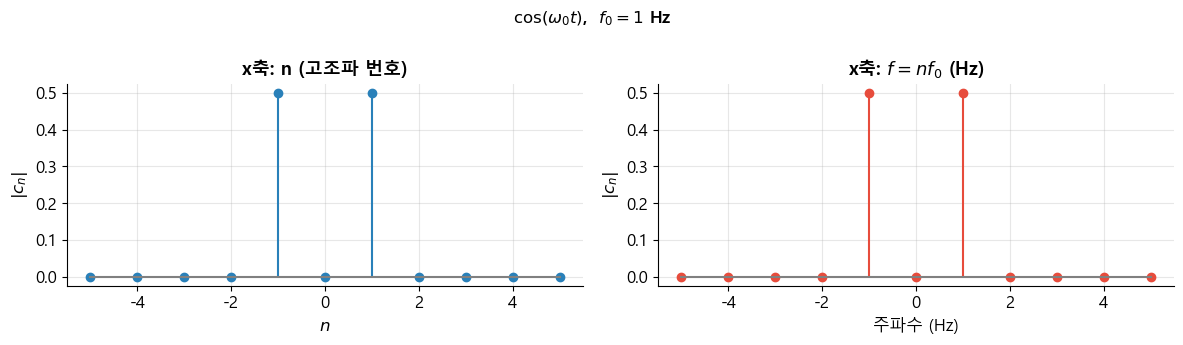

In [4]:
f0 = 1
w0 = 2 * sp.pi * f0
x = sp.cos(w0 * t)
cn = compute_cn(x, f0)

fig = plot_cn_n_vs_hz(cn, f0, title=r"$\cos(\omega_0 t)$,  $f_0 = 1$ Hz")

C:\Users\User\AppData\Local\Temp\ipykernel_118876\3667282958.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


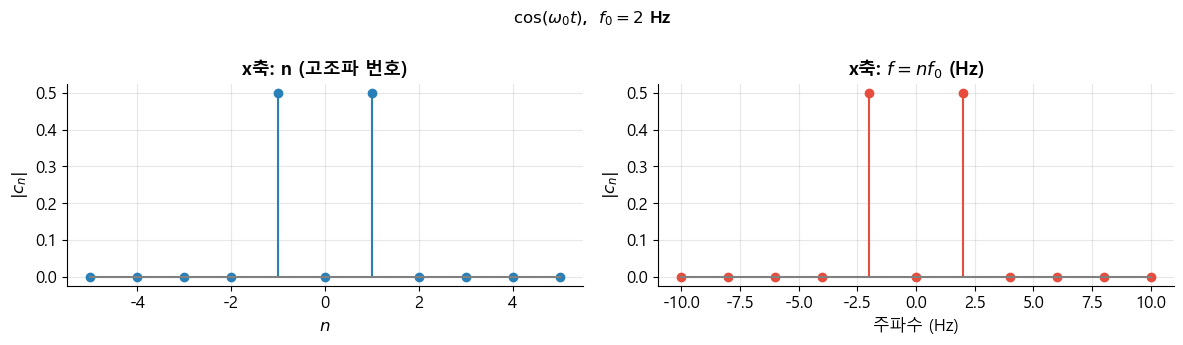

In [5]:
f0 = 2
w0 = 2 * sp.pi * f0
x = sp.cos(w0 * t)
cn = compute_cn(x, f0)

fig = plot_cn_n_vs_hz(cn, f0, title=r"$\cos(\omega_0 t)$,  $f_0 = 2$ Hz")

- **$n$ 축 (왼쪽)**: $f_0$가 달라도 $c_{\pm1} = 1/2$로 동일. $c_n$은 파형의 **형태**만 반영한다.
- **Hz 축 (오른쪽)**: $f_0 = 1$이면 $\pm1$ Hz, $f_0 = 2$이면 $\pm2$ Hz에 피크. 간격이 $f_0$만큼 벌어진다.

이후 실습에서는 **주파수(Hz) 축**으로 표시한다.

---
## 실습 1: $e^{+j\omega_0 t}$ — 양의 주파수 기저 함수

복소지수함수는 푸리에 급수의 **기저 함수** 그 자체다.
$e^{j\omega_0 t}$는 이미 "1개의 항"이므로, $c_1 = 1$이고 나머지는 모두 0이어야 한다.

In [6]:
f0 = 1
w0 = 2 * sp.pi * f0

x = sp.exp(sp.I * w0 * t)
cn = compute_cn(x, f0)

for n, c in cn.items():
    print(f"n={n:+d}: {c}")

n=-5: 0
n=-4: 0
n=-3: 0
n=-2: 0
n=-1: 0
n=+0: 0
n=+1: 1
n=+2: 0
n=+3: 0
n=+4: 0
n=+5: 0


c:\Users\User\OneDrive\00_수업 관련 업무\00_참고자료\신호처리 Lecture Note\notebooks\utils\plotting.py:187: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


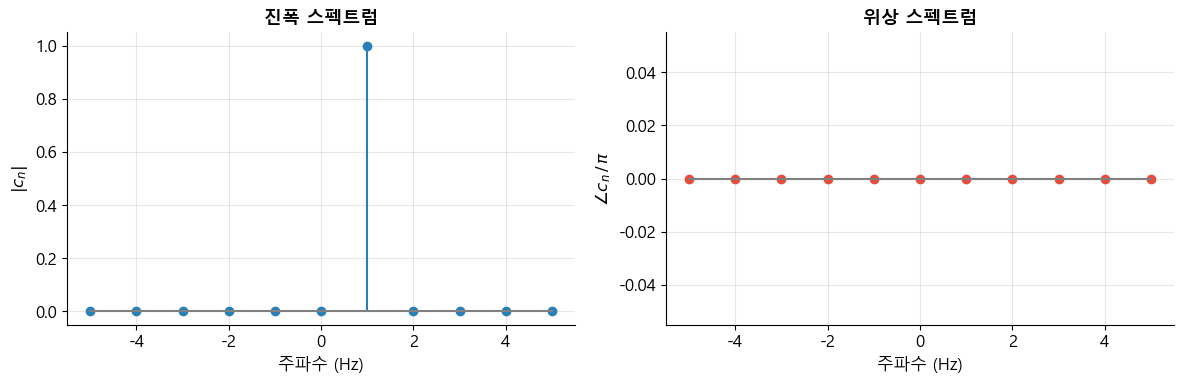

In [7]:
fig = plot_fourier_coeffs(cn, f0=f0)

$c_{+1} = 1$만 존재한다. $+f_0$에 피크 1개.

### 직접 해보기

1. $e^{j \cdot 3\omega_0 t}$의 계수를 구하면 $c_3 = 1$이 나오는가?
2. $2 e^{j\omega_0 t}$이면 $c_1$이 어떻게 달라지는가?

---
## 실습 2: $e^{-j\omega_0 t}$ — 음의 주파수

부호가 반대이면 음의 주파수에 피크가 나타나야 한다.

In [8]:
f0 = 1
w0 = 2 * sp.pi * f0

x = sp.exp(-sp.I * w0 * t)
cn = compute_cn(x, f0)

for n, c in cn.items():
    print(f'n={n:+d}: {c}')

n=-5: 0
n=-4: 0
n=-3: 0
n=-2: 0
n=-1: 1
n=+0: 0
n=+1: 0
n=+2: 0
n=+3: 0
n=+4: 0
n=+5: 0


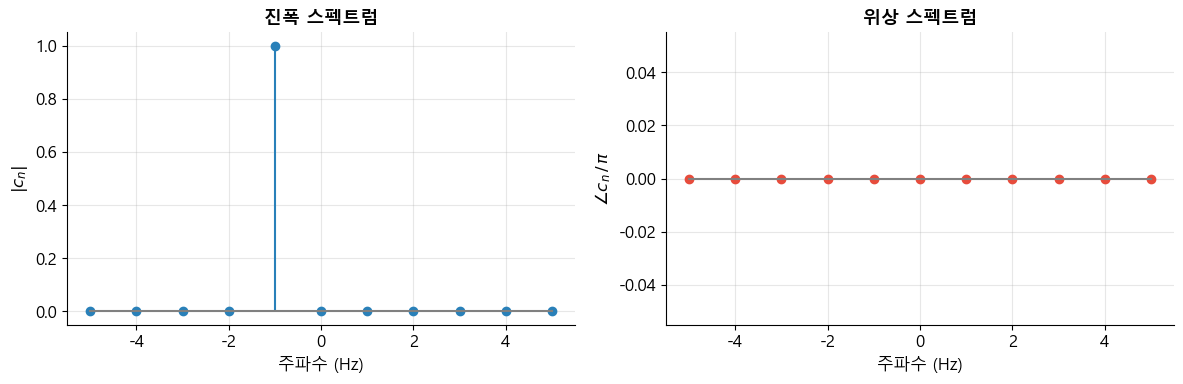

In [9]:
fig = plot_fourier_coeffs(cn, f0=f0)

$c_{-1} = 1$만 존재한다. $-f_0$에 피크 1개.

$e^{+j\omega_0 t}$와 $e^{-j\omega_0 t}$는 푸리에 급수의 "원자"이다. 다른 모든 주기 신호는 이들의 조합이다.

### 직접 해보기

1. $e^{-j \cdot 2\omega_0 t}$이면 피크가 어디에 나타나는가?
2. $e^{+j\omega_0 t} + e^{-j\omega_0 t}$의 계수를 구해보자. 결과가 익숙한가?

---
## 실습 3: $\cos(\omega_0 t)$ — 실수 신호의 양면 스펙트럼

오일러 공식에 의해:

$$\cos(\omega_0 t) = \frac{1}{2}e^{+j\omega_0 t} + \frac{1}{2}e^{-j\omega_0 t}$$

실습 1, 2의 결과를 반씩 합치면 $c_{+1} = c_{-1} = 1/2$가 되어야 한다.

In [10]:
f0 = 1
w0 = 2 * sp.pi * f0

x = sp.cos(w0 * t)
cn = compute_cn(x, f0)

for n, c in cn.items():
    print(f'n={n:+d}: {c}')

n=-5: 0
n=-4: 0
n=-3: 0
n=-2: 0
n=-1: 1/2
n=+0: 0
n=+1: 1/2
n=+2: 0
n=+3: 0
n=+4: 0
n=+5: 0


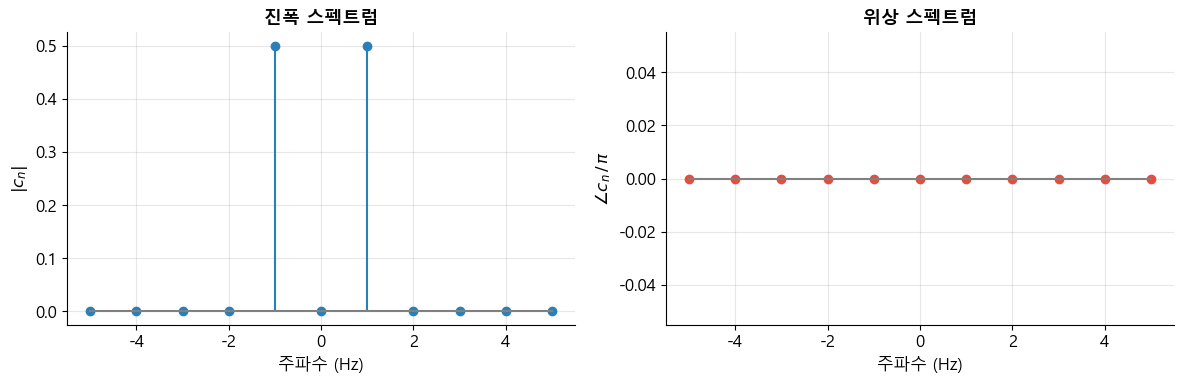

In [11]:
fig = plot_fourier_coeffs(cn, f0=f0)

- $c_{\pm1} = 1/2$: 진폭 1의 **정확히 절반**씩 양쪽에 나뉜다.
- 이것이 실수 신호의 스펙트럼이 $\pm f_0$에 피크를 갖는 이유다.
- 실수 신호 → 항상 $c_{-n} = c_n^*$ (켤레 대칭).

### 진폭과 위상이 있는 경우

$x(t) = A\cos(\omega_0 t + \phi)$이면 $c_{\pm1} = \frac{A}{2}e^{\pm j\phi}$이다.

In [12]:
f0 = 100
w0 = 2 * sp.pi * f0

x = 3 * sp.cos(w0 * t + sp.pi / 6)
cn = compute_cn(x, f0)

for n, c in cn.items():
    print(f'n={n:+d}: {c}')

n=-5: 0
n=-4: 0
n=-3: 0
n=-2: 0
n=-1: 3*exp(-I*pi/6)/2
n=+0: 0
n=+1: 3*exp(I*pi/6)/2
n=+2: 0
n=+3: 0
n=+4: 0
n=+5: 0


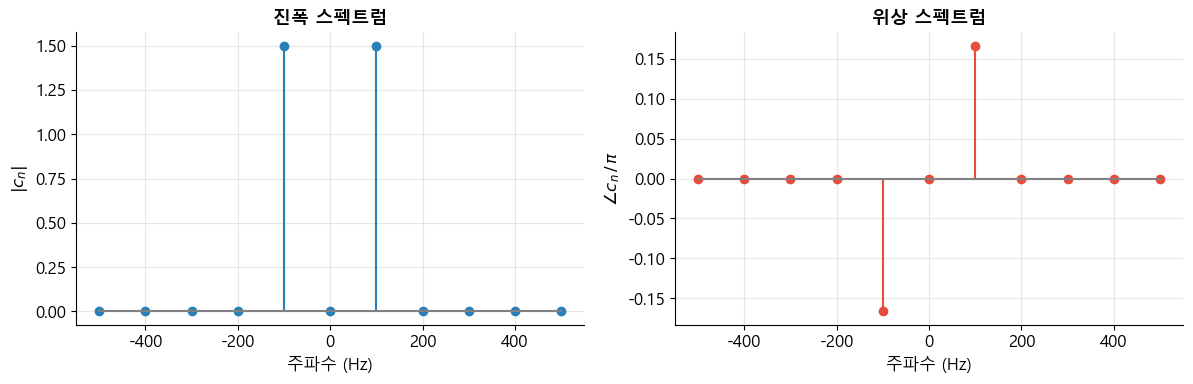

In [13]:
fig = plot_fourier_coeffs(cn, f0=f0)

- $|c_{\pm1}| = 3/2$: 원래 진폭 3의 절반
- $\angle c_1 = +\pi/6$, $\angle c_{-1} = -\pi/6$: 초기 위상이 그대로 반영
- 켤레 대칭 $c_{-1} = c_1^*$ 확인

### 직접 해보기

1. $\sin(\omega_0 t)$의 계수를 구해보자. $\cos$과 비교했을 때 위상이 어떻게 다른가?
2. $\cos(\omega_0 t) + \cos(3\omega_0 t)$이면 0이 아닌 $c_n$은 몇 개인가?

---
## 실습 4: 사각파 — 무한히 많은 고조파가 필요한 신호

진폭 $\pm1$, 주기 $T$인 사각파:

$$x(t) = \begin{cases} +1 & 0 < t < T/2 \\ -1 & T/2 < t < T \end{cases}$$

이 신호는 홀수 고조파만 포함하며, 계수는 $1/n$으로 감소한다.

In [14]:
f0 = 1
w0 = 2 * sp.pi * f0
T = sp.Integer(1) / sp.Integer(f0)

x = sp.Piecewise((1, t < T / 2), (-1, True))
cn = compute_cn(x, f0, n_range=10)

for n, c in cn.items():
    print(f'n={n:+d}: {c}')

n=-10: 0
n=-9: 2*I/(9*pi)
n=-8: 0
n=-7: 2*I/(7*pi)
n=-6: 0
n=-5: 2*I/(5*pi)
n=-4: 0
n=-3: 2*I/(3*pi)
n=-2: 0
n=-1: 2*I/pi
n=+0: 0
n=+1: -2*I/pi
n=+2: 0
n=+3: -2*I/(3*pi)
n=+4: 0
n=+5: -2*I/(5*pi)
n=+6: 0
n=+7: -2*I/(7*pi)
n=+8: 0
n=+9: -2*I/(9*pi)
n=+10: 0


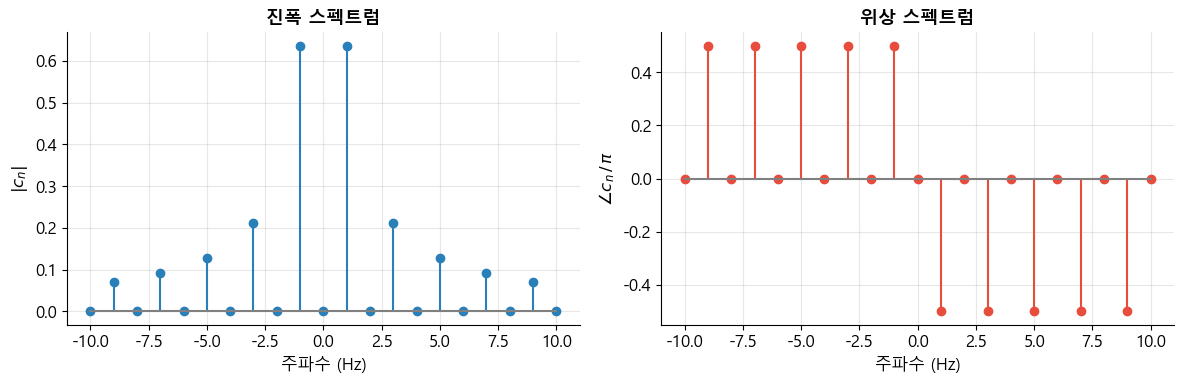

In [15]:
fig = plot_fourier_coeffs(cn, f0=f0)

- 홀수 $n$에서만 $c_n \neq 0$: 사각파의 반파 대칭 때문이다.
- $|c_n| = 2/(\pi n)$으로 감소 — 불연속점이 있으면 $1/n$ 감소.
- 위상은 $\pm\pi/2$: 순수 사인 성분 ($c_n$이 순허수).

### 부분합: 항을 더할수록 사각파에 수렴

c:\Users\User\OneDrive\00_수업 관련 업무\00_참고자료\신호처리 Lecture Note\notebooks\utils\plotting.py:217: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


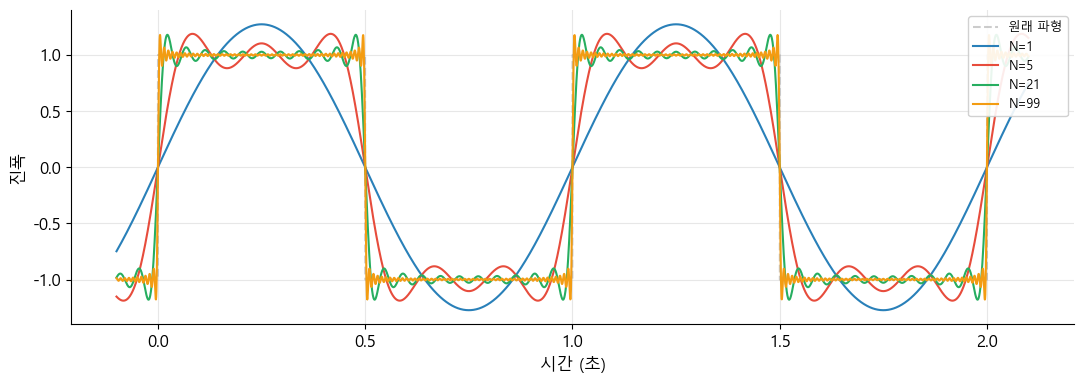

In [16]:
f0 = 1
t_num = np.linspace(-0.1, 2.1, 4000)
square = np.sign(np.sin(2 * np.pi * f0 * t_num))

sums = [(square_wave_fourier(t_num, f0, N), f'N={N}') for N in [1, 5, 21, 99]]

fig = plot_partial_sum(t_num, square, sums)

- $N=1$: 순수 사인파 1개
- $N=99$: 거의 사각파이지만, 불연속점에서 오버슈트가 남아 있다

이 오버슈트가 **Gibbs 현상**이다. 항 수를 아무리 늘려도 계단 높이의 약 9%가 유지된다.

### 직접 해보기

1. 삼각파(`sp.Piecewise((4*t/T - 1, t < T/2), (3 - 4*t/T, True))`)의 $c_n$을 구해보자. $1/n^2$으로 감소하는가?
2. N=999를 넣으면 Gibbs 오버슈트가 줄어드는가?
3. `f0`를 2로 바꾸고 다시 실행해보자. Hz축 스펙트럼이 어떻게 달라지는가?

---
## 정리

| 신호 | 0이 아닌 $c_n$ | 핵심 |
|------|---------------|------|
| $e^{j\omega_0 t}$ | $c_1 = 1$ | 기저 함수 자체 |
| $e^{-j\omega_0 t}$ | $c_{-1} = 1$ | 음의 주파수 기저 |
| $\cos(\omega_0 t)$ | $c_{\pm1} = 1/2$ | 실수 = 양쪽 회전의 합 |
| 사각파 | $c_n = -2j/(\pi n)$ (홀수) | 불연속 → $1/n$ 감소 |

$c_n$은 파형의 **형태**를 나타내고, 실제 주파수는 $f = n \times f_0$으로 결정된다.

### 핵심 수식

$$c_n = \frac{1}{T}\int_0^T x(t)\, e^{-jn\omega_0 t}\, dt$$

### 다음 실습 예고

주기 $T \to \infty$로 보내면 이산 스펙트럼이 연속으로 바뀐다 — 푸리에 변환.